In [1]:
# code from snap to parse the data
import pandas as pd
import gzip
import json
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

In [2]:
def parse(path):
  g = gzip.open(path, 'rb')
  for l in g:
    yield json.loads(l)

def getDF(path):
  i = 0
  df = {}
  for d in parse(path):
    df[i] = d
    i += 1
  return pd.DataFrame.from_dict(df, orient='index')

df = getDF('Video_Games_5.json.gz')
print("Checking Null values\n")
print(df.isnull().sum())

#get the sample data head  
print(df.head()) # function to get the front part of the table

Checking Null values

overall                0
verified               0
reviewTime             0
reviewerID             0
asin                   0
reviewerName          76
reviewText           158
summary              109
unixReviewTime         0
vote              389784
style             208340
image             493943
dtype: int64
   overall  verified   reviewTime      reviewerID        asin  \
0      5.0      True  10 17, 2015  A1HP7NVNPFMA4N  0700026657   
1      4.0     False  07 27, 2015  A1JGAP0185YJI6  0700026657   
2      3.0      True  02 23, 2015  A1YJWEXHQBWK2B  0700026657   
3      2.0      True  02 20, 2015  A2204E1TH211HT  0700026657   
4      5.0      True  12 25, 2014  A2RF5B5H74JLPE  0700026657   

        reviewerName                                         reviewText  \
0        Ambrosia075  This game is a bit hard to get the hang of, bu...   
1             travis  I played it a while but it was alright. The st...   
2  Vincent G. Mezera                             

## PART 1 Basic Information and data versifications

In [3]:
# generating each column 
ratings = [] # rating of the product
vers = [] 
times = [] 
reviewerIDs = []
asins = [] #ID of the produc
reviews = set(df['summary'])

for review in parse("Video_Games_5.json.gz"):
    ratings.append(review['overall'])
    vers.append(review['verified'])
    times.append(review['reviewTime'])
    reviewerIDs.append(review['reviewerID'])
    asins.append(review['asin'])


5.0    299759
4.0     93654
3.0     49146
1.0     30883
2.0     24135
Name: overall, dtype: int64 

Average ratings: 4.220456331381876 
 


Text(0.5, 1.0, 'Rating Counts')

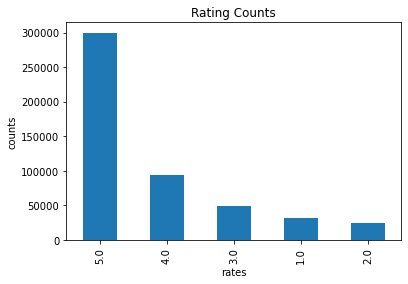

In [4]:
# clean and integrate data
# double check the column data, get the sameple data  

#avg ratings for game category 
rates_count= df['overall'].value_counts()
print(rates_count,'\n')

rate_avg = sum(ratings) / len(ratings)
print("Average ratings: {} \n ".format(rate_avg))

plt = rates_count.plot(kind='bar')
plt.set_xlabel('rates')
plt.set_ylabel('counts')
plt.set_title('Rating Counts')

Count True: 332645, Count False:164932. Total:497577 

{False, True}




Text(0.5, 1.0, 'Verification Counts Percentage')

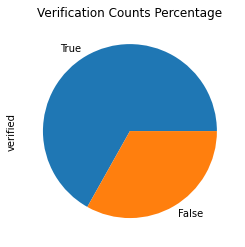

In [5]:
# verified
print("Count True: {}, Count False:{}. Total:{} \n".format(vers.count(True), vers.count(False), len(vers)))
print(set(df['verified'])) # verify any mistype
print("\n")

ver_counts= df['verified'].value_counts()
plt = ver_counts.plot(kind='pie')
plt.set_title('Verification Counts Percentage')

      


Pass date check 
num times total:  497577
num of same date :  6847




<AxesSubplot:>

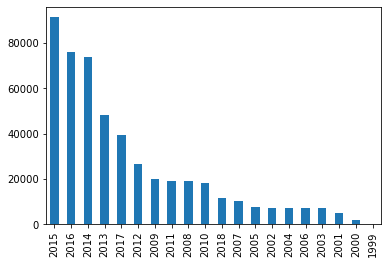

In [6]:
# review date
for i in range(df.shape[0]):
    YYYY = times[i].split(',')[-1] 
    MM = times[i].split(' ')[0] 
    DD = times[i].split(',')[0].split(' ')[1]
    if (MM > '12') or (MM < '01'):
        print(i,"M-F")
        
    if (int(DD) > 31) or (int(DD) < 1):
        print(i,DD, "D-F")
print("Pass date check ")

from datetime import datetime
print("num times total: ", len(times))
print("num of same date : ", len(df.reviewTime.unique()))
#unixtime
# print(len(df.reviewTime.unique()) == len(df.unixReviewTime.unique()))
# print(datetime.fromtimestamp(min(df.unixReviewTime.unique())))
# print(datetime.fromtimestamp(max(df.unixReviewTime.unique())))
print("\n")

year_list = set([i.split(',')[-1] for i in times])
year_list = sorted(year_list)

df["unixReviewTime"] = pd.to_datetime(df["unixReviewTime"], unit='s')
df["unixReviewTime"]
df["year"] = df["unixReviewTime"].dt.year


df["year"].value_counts().plot(kind='bar')


In [7]:

# reviewer
print(len(reviewerIDs))
print(len(set(df['reviewerID'])))
print("num of reviewer : ", len(df.reviewerID.unique()))

print(max(df["reviewerID"].value_counts()))

print("\n")

df["reviewerID"].value_counts()

497577
55223
num of reviewer :  55223
815




A3V6Z4RCDGRC44    815
AJKWF4W7QD4NS     795
A3W4D8XOGLWUN5    521
A2QHS1ZCIQOL7E    472
A2TCG2HV1VJP6V    453
                 ... 
AADZHZTODQRKB       5
A2QL99F4W9IB3E      5
A28C2PAK06VJ4L      4
A1I75X6T38Y4UW      4
A1HV707K7KWQP0      4
Name: reviewerID, Length: 55223, dtype: int64

In [8]:
#products
print(len(asins))
print("num of products : ", len(df.asin.unique()))
df.asin.value_counts()
# print("\n")



497577
num of products :  17408


B00178630A    1381
B000ZK9QCS     905
B000XJNTNS     834
B00JK00S0S     783
B000ZKA0J6     774
              ... 
B000XJD33E       1
B000WZ7OD4       1
B000WKW6AU       1
B000W2UJ2A       1
B000WMJM3W       1
Name: asin, Length: 17408, dtype: int64

[nan, 'Tomb Raider Underworld for PS3', 'Call of Duty in the beginning', 'Look cool, hurt head', 'Blast to the Past', 'Get These!!', 'Is this the start of the decline of Skylanders? UPDATE:"Losing Saved Game due to Glitchiness!!***', 'A Great Sega Gensis classic', 'Essential for Every Xbox', "I don't like this game, is better the olders Bournout"]




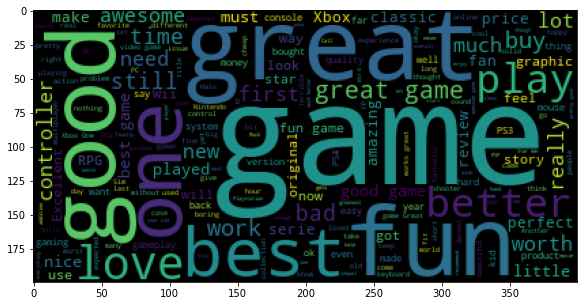

In [9]:
# reviews

list_reviews = list(reviews)
print(list_reviews[:10])
print("\n")

import matplotlib.pyplot as plt
worldcloud = WordCloud().generate("".join(list_reviews[1:]))
plt.figure(figsize = (15,5))
plt.imshow(worldcloud)
# ax1 = fig.add_subplot(2,2,1)
# ax1.imshow(worldcloud)



#reviewText

# text = df['reviewText']
# print(text.isnull().sum())
# newtext = []
# #remove all none 
# for i in text:
#     if type(i) == type('str') :
#         newtext.append(i)

# print(len(newtext))

# textcloud = WordCloud().generate("".join(newtext))
# ax2 = fig.add_subplot(2,2,2)
# ax2.imshow(textcloud)

# Part 3 More Anlysis

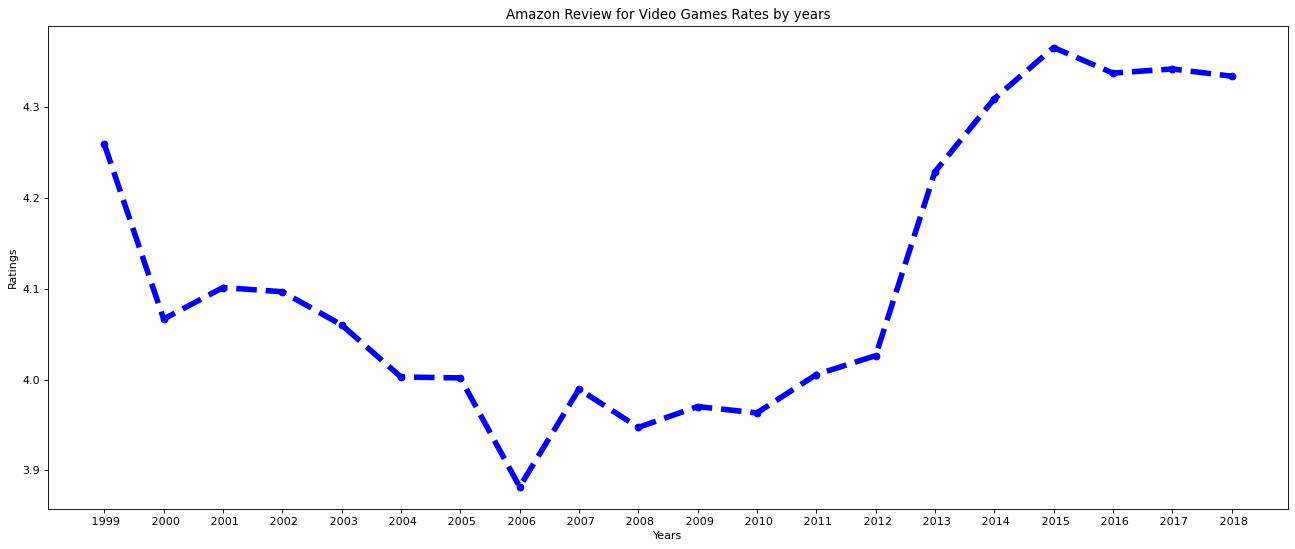

In [10]:

# ratings on the years

import matplotlib.pyplot as plt


#df.head()

year_table = df[['year', 'overall']].groupby('year').mean()
#print(year_table)


plt.figure(figsize=(20, 8), dpi=80)
plt.plot(list(year_list), year_table.iloc[:,0], '--bo', lw=5)
plt.xlabel('Years')
plt.ylabel('Ratings')
plt.title('Amazon Review for Video Games Rates by years') 
plt.show()

overall              0
verified             0
reviewTime           0
reviewerID           0
asin                 0
reviewerName         0
reviewText           0
summary              1
unixReviewTime       0
vote              2737
style             4334
image             7764
year                 0
dtype: int64
4.001797868241941


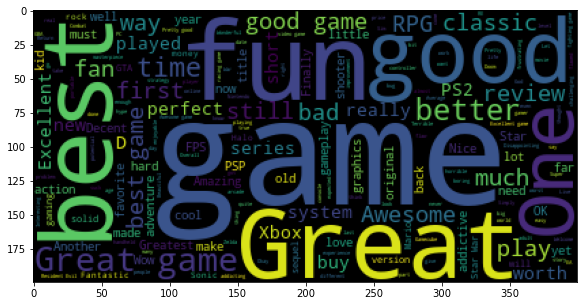

In [12]:
#2005 has the lowest avg review, check the review here 

low_df = df[df.year.eq(2005)]

print(low_df.isnull().sum())
print(low_df.overall.mean())

# get the word cloud 
text = low_df['summary']
newtext = []
#remove all none 
for i in text:
    if type(i) == type('str') :
        newtext.append(i)
textcloud = WordCloud().generate(" ".join(newtext))# gather all text 
plt.figure(figsize=(15,5))
plt.imshow(textcloud)

##  Linear Prediction based on the current data 
    -> observe: The data is not suitable for this modeal

Rate for total regression 0.002569556141390772
Predict for total regression: 4.149346881320194
67
Rate for regression starting from 2010 0.019232709006389286
	 2023 Predict for regression 2010: 4.281527838218722


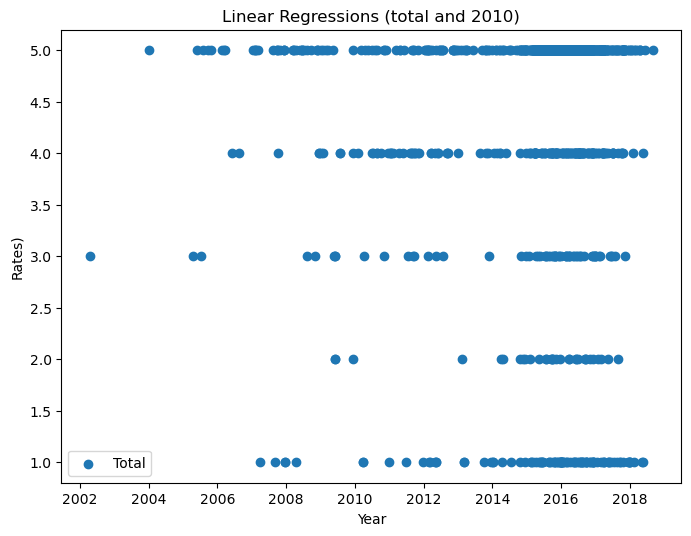

In [11]:
import numpy as np
from sklearn.linear_model import LinearRegression


df_predict = df.copy().dropna()
df_predict.sort_values(by='unixReviewTime', inplace=True)



column = df_predict.overall.tolist()
years = df_predict.unixReviewTime.tolist() 
plt.subplots(figsize=(8,6),dpi=100)
plt.scatter(years,column,marker='o',label='Total')

for i in range(len(years)):
    years[i] = years[i].year  
# print(years)
lr = LinearRegression()
lr.fit(np.reshape(years,(-1,1)),np.reshape(column,(-1,1)))
# plt.plot(years, lr.predict(np.reshape(years,(-1,1))),label='Total Predition')
print('Rate for total regression',lr.coef_[0][0])
print('Predict for total regression:',lr.predict([[2020]])[0][0])

# get data ater 2010 because we obser only very less data before 2010

# finmd the index for 2010
index_2010 = -1
for i in range(len(years)):
    if years[i] == 2010:
        index_2010 = i
        break
print(index_2010)
    
lr = LinearRegression()
lr.fit(np.reshape(years[index_2010:],(-1,1)),np.reshape(column[index_2010:],(-1,1)))
# plt.plot(years[index_2010:], lr.predict(np.reshape(years[index_2010:],(-1,1))),label='Prediction starts from 2005')
print('Rate for regression starting from 2010',lr.coef_[0][0])
print('\t 2023 Predict for regression 2010:',lr.predict([[2020]])[0][0])
plt.ylabel('Rates)')
plt.xlabel('Year')
plt.title('Linear Regressions (total and 2010)')
plt.legend()
plt.show()

# Plan: Decison Tree
 -> Simple Decision Tree positive ( rates 4/5) or negative (rates: 1/2)
 -> postive words from review or negetive words etc,

In [ ]:
# Simple Decision Tree positive ( rates 4/5) or negative (rates: 1/2)

# from nltk.probability import FreDist

# import nltk


# tokens = nltk.word_tokenize(" ".join(list_reviews[1:])) 

# tokens


# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(df['overall'], df['overall'], test_size=0.2, random_state=0)

# from sklearn.tree import DecisionTreeClassifier
# clf_dt = DecisionTreeClassifier()

# clf_dt.fit(X_train, y_train)

In [13]:
# rating on each users(top 10) 

# rating for each products ()

## Simple NLP analysis

In [14]:
index_list = list(range(0,len(df)))

df.insert(0,"Index", index_list, True)
df.head()

,Index,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image,year
0,0,5.0,True,"10 17, 2015",A1HP7NVNPFMA4N,0700026657,Ambrosia075,"This game is a bit hard to get the hang of, bu...",but when you do it's great.,2015-10-17,NaN,NaN,NaN,2015
1,1,4.0,False,"07 27, 2015",A1JGAP0185YJI6,0700026657,travis,I played it a while but it was alright. The st...,"But in spite of that it was fun, I liked it",2015-07-27,NaN,NaN,NaN,2015
2,2,3.0,True,"02 23, 2015",A1YJWEXHQBWK2B,0700026657,Vincent G. Mezera,ok game.,Three Stars,2015-02-23,NaN,NaN,NaN,2015
3,3,2.0,True,"02 20, 2015",A2204E1TH211HT,0700026657,Grandma KR,"found the game a bit too complicated, not what...",Two Stars,2015-02-20,NaN,NaN,NaN,2015
4,4,5.0,True,"12 25, 2014",A2RF5B5H74JLPE,0700026657,jon,"great game, I love it and have played it since...",love this game,2014-12-25,NaN,NaN,NaN,2014


In [15]:

# reference: https://medium.com/@suntarekar/vader-for-sentiment-analysis-a29f3f1dbcad

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

SIA = SentimentIntensityAnalyzer()
results = {}
for i,row in tqdm(df.iterrows(), total=len(df)):
    text=row['reviewText']
    myid=row['Index']
    if type(text) == type('str'):
        results[myid]=SIA.polarity_scores(text)
    else:
        results[myid] = 'SKIP'

# Vaders=pd.DataFrame(results).T
# # Vaders= Vaders.reset_index().rename(columns={'index': 'Id'})
# Vaders = Vaders.merge(df,how='left')
# Vaders

  0%|          | 0/497577 [00:00<?, ?it/s]

In [16]:
# for i in range(10):
#     print(results.get(i))
# print(len(results))
# print(len(df))

# reference: https://medium.com/@suntarekar/vader-for-sentiment-analysis-a29f3f1dbcad
# Title: VADER for Sentiment Analysis ; by Sanjana Tarekar

Vaders=pd.DataFrame(results).T
Vaders= Vaders.reset_index().rename(columns={'index': 'Index'})
Vaders = Vaders.merge(df, how='left')
Vaders

,Index,neg,neu,pos,compound,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image,year
0,0,0.058,0.671,0.271,0.7543,5.0,True,"10 17, 2015",A1HP7NVNPFMA4N,0700026657,Ambrosia075,"This game is a bit hard to get the hang of, bu...",but when you do it's great.,2015-10-17,NaN,NaN,NaN,2015
1,1,0.132,0.61,0.259,0.8302,4.0,False,"07 27, 2015",A1JGAP0185YJI6,0700026657,travis,I played it a while but it was alright. The st...,"But in spite of that it was fun, I liked it",2015-07-27,NaN,NaN,NaN,2015
2,2,0.0,0.312,0.688,0.296,3.0,True,"02 23, 2015",A1YJWEXHQBWK2B,0700026657,Vincent G. Mezera,ok game.,Three Stars,2015-02-23,NaN,NaN,NaN,2015
3,3,0.0,0.862,0.138,0.34,2.0,True,"02 20, 2015",A2204E1TH211HT,0700026657,Grandma KR,"found the game a bit too complicated, not what...",Two Stars,2015-02-20,NaN,NaN,NaN,2015
4,4,0.0,0.428,0.572,0.8934,5.0,True,"12 25, 2014",A2RF5B5H74JLPE,0700026657,jon,"great game, I love it and have played it since...",love this game,2014-12-25,NaN,NaN,NaN,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497572,497572,0.383,0.617,0.0,-0.4782,4.0,True,"07 1, 2017",AVECM71LSZLC5,B01HGPUTCA,boris teplitskiy,not OEM but good replacement parts,Four Stars,2017-07-01,NaN,NaN,NaN,2017
497573,497573,0.0,0.345,0.655,0.2263,3.0,True,"08 20, 2018",A1RS06313BL6WN,B01HH6JEOC,Tom Stopsign,Okay stuff.,Three Stars,2018-08-20,NaN,"{'Edition:': ' Kids Room', 'Platform:': ' PC O...",NaN,2018
497574,497574,0.0,0.933,0.067,0.5418,3.0,True,"08 7, 2017",ACIZ77IGIX2JL,B01HH6JEOC,Era,This does add some kids room things that are v...,Only buy on sale.,2017-08-07,NaN,"{'Edition:': ' Kids Room', 'Platform:': ' PC O...",NaN,2017
497575,497575,0.153,0.729,0.118,-0.9861,4.0,False,"08 5, 2018",A34GG58TJ1A3SH,B01HIZF7XE,seamonkey10,I think I originally began playing Bioshock se...,"It's Okay, Nothing Profound",2018-08-05,NaN,"{'Edition:': ' Collection', 'Platform:': ' Xbo...",NaN,2018


In [17]:
# remove the null values above for vaders, "reviewText" == null
#Data cleaning
print(Vaders.isnull().sum())
Vaders.dropna(subset=['reviewText'], inplace=True)
print(Vaders.isnull().sum())

Index                  0
neg                    0
neu                    0
pos                    0
compound               0
overall                0
verified               0
reviewTime             0
reviewerID             0
asin                   0
reviewerName          76
reviewText           158
summary              109
unixReviewTime         0
vote              389784
style             208340
image             493943
year                   0
dtype: int64
Index                  0
neg                    0
neu                    0
pos                    0
compound               0
overall                0
verified               0
reviewTime             0
reviewerID             0
asin                   0
reviewerName          76
reviewText             0
summary              103
unixReviewTime         0
vote              389635
style             208296
image             493819
year                   0
dtype: int64


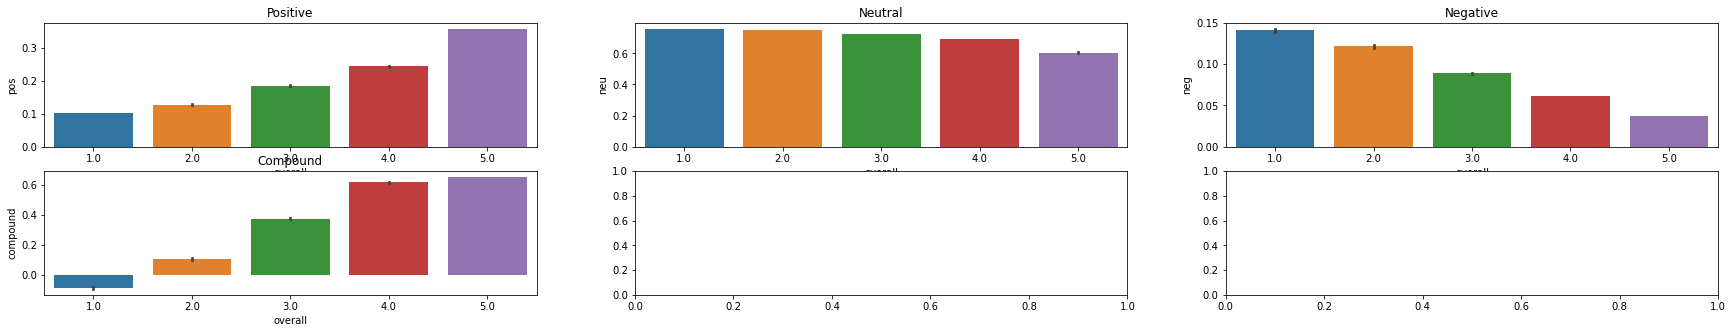

In [18]:
# sia_table = Vaders[['neg', 'neu', 'pos', 'compound', 'overall']].groupby('overall').mean()
# sia_table

# reference: https://medium.com/@suntarekar/vader-for-sentiment-analysis-a29f3f1dbcad
# Title: VADER for Sentiment Analysis ; by Sanjana Tarekar

import seaborn as sns
fig, ax = plt.subplots(2, 3, figsize=(30, 5))
sns.barplot(ax=ax[0][0], data=Vaders, x='overall', y='pos')
ax[0][0].set_title('Positive')
sns.barplot(ax=ax[0][1], data=Vaders, x='overall', y='neu')
ax[0][1].set_title('Neutral')
sns.barplot(ax=ax[0][2], data=Vaders, x='overall', y='neg')
ax[0][2].set_title('Negative')
sns.barplot(ax=ax[1][0], data=Vaders, x='overall', y='compound')
ax[1][0].set_title('Compound')
plt.show()